# FINM3422 – Lecture 5 In‑Class Notebook (Foundations)
Use this during the lecture. Cells marked **TODO (lecture)** are completed live in class.


In [ ]:

%pip install --upgrade pip
%pip install pandas
%pip install matplotlib

In [2]:
# 0) Sanity check: Python, pandas, matplotlib
print('Hello FINM3422 👋')
import sys, pandas as pd, matplotlib.pyplot as plt
sys.version.split()[0]

Hello FINM3422 👋


'3.13.2'

## 1) Load data (prices, monthly)
We keep a tiny CSV in `data/prices_monthly.csv` with a `Date` column and a few asset columns.

In [ ]:
# TODO (lecture): Run the following code : Create a DataFrame of stock prices for two stocks A and B:
prices = pd.DataFrame({'A':[100,101,103],'B':[100,99,100]}, index=pd.to_datetime(['2020-01-31','2020-02-29','2020-03-31']))
prices.head()

,A,B
2020-01-31,100,100
2020-02-29,101,99
2020-03-31,103,100


In [6]:
# TODO (lecture): read the CSV so that Date becomes the index and is parsed as datetime
# Hints: use pd.read_csv('filename.csv', parse_dates=['Date'], index_col='Date')
# Replace the placeholder below.
import pandas as pd
#placeholder for pd.read_csv
prices = pd.read_csv("prices_monthly.csv", parse_dates=['Date'], index_col=['Date'])
prices.head()

,AUS_Equity,US_Equity,Global_Bond,Gold,Cash
Date,,,,,
2019-01-31,100.29,92.18,101.19,98.01,100.22
2019-02-28,105.68,90.72,102.47,103.23,100.15
2019-03-31,105.25,88.95,103.84,101.93,100.28
2019-04-30,98.98,88.62,104.50,88.89,100.26
2019-05-31,102.18,91.05,105.86,95.35,100.16


## 2) Inspect quickly
Use `.info()`, `.head()`, and `.describe()` to build trust in the table before modelling.

In [ ]:
prices.info()
display(prices.head())
display(prices.describe())

## 3) Compute simple returns
We want fractional monthly returns from prices.

In [ ]:
# TODO (lecture): fill in pct_change to compute returns
# returns = prices.____().dropna()
returns = prices.pct_change().dropna()
returns.head()

,AUS_Equity,US_Equity,Global_Bond,Gold,Cash
Date,,,,,
2019-02-28,0.053744,-0.015839,0.012649,0.053260,-0.000698
2019-03-31,-0.004069,-0.019511,0.013370,-0.012593,0.001298
2019-04-30,-0.059572,-0.003710,0.006356,-0.127931,-0.000199
2019-05-31,0.032330,0.027420,0.013014,0.072674,-0.000997
2019-06-30,0.016735,0.006590,-0.001889,-0.030309,0.001098


## 4) Ensure monthly labels
Label the index monthly (no aggregation).

In [10]:
# TODO (lecture): use asfreq to set a monthly frequency label
# returns = returns.____('ME')
returns = returns.asfreq('ME')
returns.index.freq

<MonthEnd>

## 5) Wealth index & one plot
From returns to an indexed wealth curve (start = 1.0).

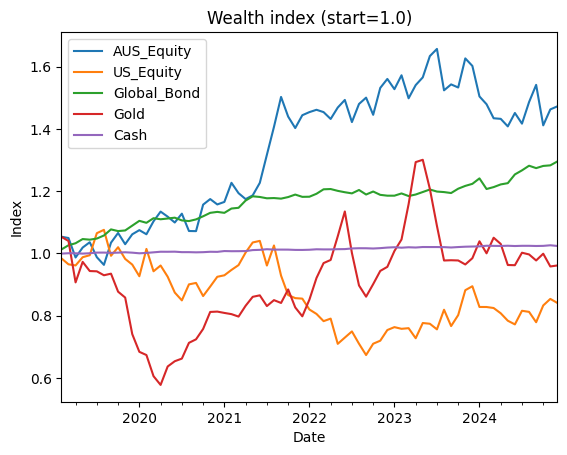

In [11]:
# TODO (lecture): complete the one-liner for wealth index
import matplotlib.pyplot as plt
# wealth = (1 + returns).____().cumprod()
wealth = (1 + returns).cumprod()
ax = wealth.plot(title='Wealth index (start=1.0)')
ax.set_xlabel('Date'); ax.set_ylabel('Index'); plt.show()

## 6) Stretch: handle missing values (choose & document)
Decide whether to `ffill`, `bfill`, or `dropna`, and *state why*.

In [15]:
# OPTIONAL TODO (lecture/tutorial): experiment with missing-data handling
returns_clean = returns.dropna()
returns_clean.head()

,AUS_Equity,US_Equity,Global_Bond,Gold,Cash
Date,,,,,
2019-02-28,0.053744,-0.015839,0.012649,0.053260,-0.000698
2019-03-31,-0.004069,-0.019511,0.013370,-0.012593,0.001298
2019-04-30,-0.059572,-0.003710,0.006356,-0.127931,-0.000199
2019-05-31,0.032330,0.027420,0.013014,0.072674,-0.000997
2019-06-30,0.016735,0.006590,-0.001889,-0.030309,0.001098


## 7) Save figure (optional)
Saving outputs makes your work reproducible.

In [17]:
# OPTIONAL: save plot
import os
os.makedirs('outputs', exist_ok=True)
ax = wealth.plot(title='Wealth index (saved)')
plt.savefig('outputs/wealth_index.png', dpi=150); plt.close()
'Saved to outputs/wealth_index.png'

'Saved to outputs/wealth_index.png'